Import everything needed

In [1]:
import os
import json
import shutil
import tempfile
import time
import glob

import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import (
    AsDiscrete,
    Activations,
)

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.utils.enums import MetricReduction
from monai.networks.nets import SwinUNETR
from monai import data
from monai.data import decollate_batch
from functools import partial

import torch


print_config()

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


MONAI version: 1.4.1rc1+46.gb58e883c
Numpy version: 1.26.4
Pytorch version: 2.6.0+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: b58e883c887e0f99d382807550654c44d94f47bd
MONAI __file__: C:\Users\<username>\monai-install\MONAI\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.3
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.15.2
Pillow version: 11.1.0
Tensorboard version: 2.18.0
gdown version: 5.2.0
TorchVision version: 0.21.0+cpu
tqdm version: 4.67.1
lmdb version: 1.6.2
psutil version: 7.0.0
pandas version: 2.2.3
einops version: 0.8.1
transformers version: 4.40.2
mlflow version: 2.21.3
pynrrd version: 1.1.3
clearml version: 1.18.0

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [2]:
print("CUDA version:", torch.version.cuda)
print("Is CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

CUDA version: 12.6
Is CUDA available: True
Device name: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
NVIDIA GeForce RTX 4060 Laptop GPU

SyntaxError: invalid syntax (654725342.py, line 1)

Visualize the data (testing to check its size)

image shape: (512, 512, 75), mask shape: (512, 512, 75)


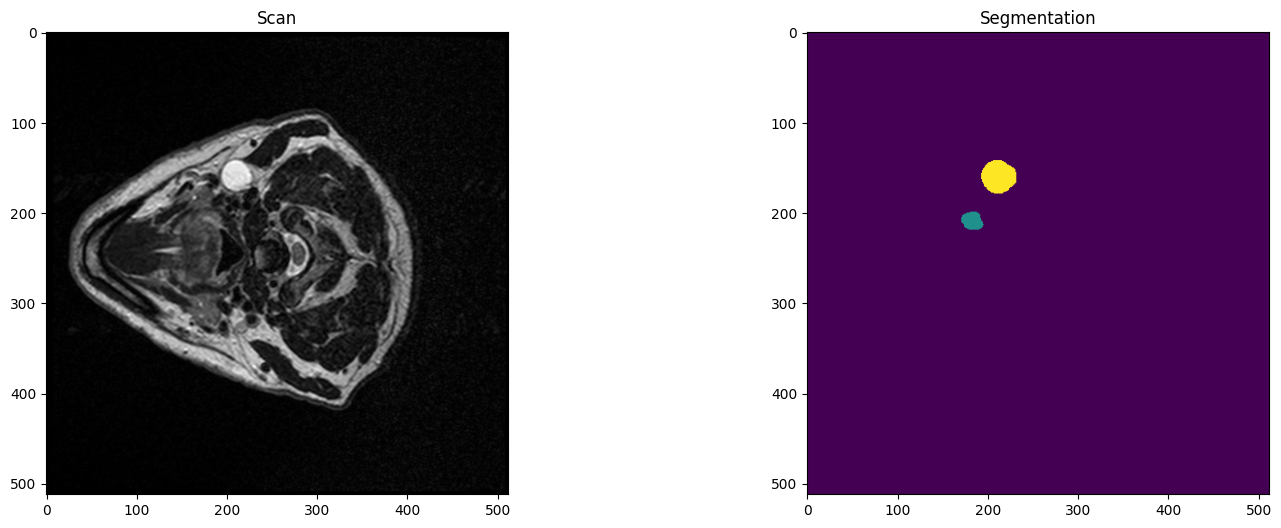

In [4]:
img_path = "C:/datasets/HNTS-MRG/train/10/preRT/10_preRT_T2.nii.gz"
mask_path = "C:/datasets/HNTS-MRG/train/10/preRT/10_preRT_mask.nii.gz"

img = nib.load(img_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print(f"image shape: {img.shape}, mask shape: {mask.shape}")

plt.figure("image", (18, 6))
plt.subplot(1, 2, 1)

plt.title("Scan")
plt.imshow(img[:, :, 40], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Segmentation")
plt.imshow(mask[:, :, 40])
plt.show()

Setup data directory

In [6]:
root_dir = tempfile.mkdtemp()
print(root_dir)

C:\Users\zapde\AppData\Local\Temp\tmp71knwuph


Setup average meter, fold reader, checkpoint saver

In [5]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = np.where(self.count > 0, self.sum / self.count, self.sum)

In [7]:
# Adjusts file paths using basedir
# Splits dataset into training and validation sets based on fold
def datafold_read(basedir, fold=0):
    tr = []
    val = []

    # Get images and masks
    images = sorted(glob.glob(basedir + "/train/*/preRT/*_preRT_T2.nii.gz"))
    masks = sorted(glob.glob(basedir + "/train/*/preRT/*_preRT_mask.nii.gz"))

    data_dicts = [{"image": img, "mask": msk} for img, msk
                  in zip(images, masks)]

    # Split data into training and validation sets
    # Should it be dict???
    tr = dict(data_dicts[int(len(data_dicts)/2):])
    val = dict(data_dicts[:int(len(data_dicts)/2)])

    tr = data_dicts[int(len(data_dicts)/2):]
    val = data_dicts[:int(len(data_dicts)/2)]

    return tr, val

In [8]:
def save_checkpoint(model, epoch, filename="model.pt",
                    best_acc=0, dir_add=root_dir):
    state_dict = model.state_dict()
    save_dict = {"epoch": epoch, "best_acc": best_acc,
                 "state_dict": state_dict}
    filename = os.path.join(dir_add, filename)
    torch.save(save_dict, filename)
    print("Saving checkpoint", filename)

Setup dataloaders

In [9]:
"""
            transforms.CropForegroundd(
                keys=["image", "mask"],
                source_key="image",
                k_divisible=[roi[0], roi[1], roi[2]],
            ),
            transforms.RandSpatialCropd(
                keys=["image", "mask"],
                roi_size=[roi[0], roi[1], roi[2]],
                random_size=False,
            ),
            """

"""
transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=0),
            transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),
            transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=2),
            transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            transforms.RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            transforms.RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),"""

def get_loader(batch_size, data_dir, fold, roi):
    data_dir = data_dir
    train_files, validation_files = datafold_read(basedir=data_dir, fold=fold)

    # Define transforms
    train_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
    transforms.EnsureChannelFirstd(keys=["image", "mask"]),
    transforms.Orientationd(keys=["image", "mask"], axcodes="RAS"),
    transforms.Spacingd(
        keys=["image", "mask"],
        pixdim=(1.0, 1.0, 1.0),  # Set based on your data
        mode=("bilinear", "nearest")
    ),
    transforms.ScaleIntensityRanged(
        keys=["image"], a_min=-1000, a_max=1000,
        b_min=0.0, b_max=1.0, clip=True,
    ),
    transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
    transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),
    transforms.ToTensord(keys=["image", "mask"]),
])
    val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
    transforms.EnsureChannelFirstd(keys=["image", "mask"]),
    transforms.Orientationd(keys=["image", "mask"], axcodes="RAS"),
    transforms.Spacingd(
        keys=["image", "mask"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "nearest")
    ),
    transforms.ScaleIntensityRanged(
        keys=["image"], a_min=-1000, a_max=1000,
        b_min=0.0, b_max=1.0, clip=True,
    ),
    transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
    transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)), # 96 is divisible by 32
    transforms.ToTensord(keys=["image", "mask"]),
])

    # Make datasets and dataloaders
    train_ds = data.Dataset(data=train_files, transform=train_transform)
    train_loader = data.DataLoader(train_ds,
        batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True,
    )
    val_ds = data.Dataset(data=validation_files, transform=val_transform)
    val_loader = data.DataLoader(val_ds,
        batch_size=1, shuffle=False, num_workers=8, pin_memory=True,
    )

    return train_loader, val_loader

Setup data directory and hyperparameters

In [10]:
data_dir = "C:/datasets/HNTS-MRG"

roi = (64,64,64) # (96,96,96)
batch_size = 1
sw_batch_size = 4
fold = 1
infer_overlap = 0.5
max_epochs = 100
val_every = 10

train_loader, val_loader = get_loader(batch_size, data_dir, fold, roi)

monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.


Create SwinUNETR model

In [11]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using " + "cuda" if torch.cuda.is_available() else "cpu")

model = SwinUNETR(
    img_size=roi,
    in_channels=1,
    out_channels=1,             # Detect two tumors (head and neck)
    feature_size=48,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    dropout_path_rate=0.0,
    use_checkpoint=True,
).to(device)

Using cuda


monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().


Define optimizer and loss function

In [12]:
torch.backends.cudnn.benchmark = True

torch.cuda.empty_cache()

from torch.cuda.amp import autocast, GradScaler

loss_function = DiceLoss(to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
dice_metric = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)

scaler = GradScaler()
max_epochs = 100

for epoch in range(max_epochs):
    print(f"Epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    for batch_data in train_loader:
        inputs, labels = batch_data["image"].to(device), batch_data["mask"].to(device)

        # Clear out the gradients of all parameters that the optimizer is tracking
        optimizer.zero_grad()

        with autocast():
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

        # Backward pass with scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        optimizer.step()

        epoch_loss += loss.item()

        print("Batch...")
    print(f"Avg loss: {epoch_loss / len(train_loader):.4f}")

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.


Epoch 1/100


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


OutOfMemoryError: CUDA out of memory. Tried to allocate 6.30 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 9.05 GiB is allocated by PyTorch, and 2.88 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Define train and validation epoch

Define trainer

Now execute training

Wed Apr 16 17:55:49 2025 Epoch: 0


KeyError: Caught KeyError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "C:\Users\zapde\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "C:\Users\zapde\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "C:\Users\zapde\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "C:\Users\zapde\monai-install\MONAI\monai\data\dataset.py", line 108, in __getitem__
    return self._transform(index)
  File "C:\Users\zapde\monai-install\MONAI\monai\data\dataset.py", line 93, in _transform
    data_i = self.data[index]
KeyError: 0
